In [1]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import numpy as np
from statsmodels.tsa.seasonal import STL, seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import het_arch
from pathlib import Path
import os
from scipy.stats import linregress


In [2]:
# loading the cleaned DataFrame

base_path = Path(os.getcwd())

input_path  = base_path / r"..\..\Data\Cleaned\df_bologna_cleaned.parquet"

df = pd.read_parquet(input_path)

In [3]:
df.head(5)

,index,time,latitude,longitude,t2m,SSRD_Wm2,CLEAR_SKY_GHI,GHI,GHI_index
0,0,2005-01-01 01:00:00,45.5,11.25,0.368042,0.0,0.0,0.0,NaN
1,1,2005-01-01 02:00:00,45.5,11.25,0.558685,0.0,0.0,0.0,NaN
2,2,2005-01-01 03:00:00,45.5,11.25,0.467987,0.0,0.0,0.0,NaN
3,3,2005-01-01 04:00:00,45.5,11.25,0.576385,0.0,0.0,0.0,NaN
4,4,2005-01-01 05:00:00,45.5,11.25,0.582214,0.0,0.0,0.0,NaN


## Agregating into daily statistics

In [4]:

df_daily = (
    df.groupby(df['time'].dt.date)
    .agg(
        t2m_mean      = ('t2m',           'mean'),
        t2m_min       = ('t2m',           'min'),
        t2m_max       = ('t2m',           'max'),
        GHI_sum       = ('GHI',           'sum'),
        GHI_cs_sum    = ('CLEAR_SKY_GHI', 'sum'),
        GHI_var       = ('GHI',           'var'),
    )
    .assign(
        t2m_range  = lambda x: x['t2m_max'] - x['t2m_min'],
        Kt_daily   = lambda x: x['GHI_sum'] / x['GHI_cs_sum']
    )
    .rename_axis('date')
    .reset_index()
)

# Reorder columns
df_daily = df_daily[['date', 't2m_mean', 't2m_min', 't2m_max', 't2m_range',
                      'GHI_sum', 'GHI_cs_sum', 'Kt_daily', 'GHI_var']]

#create the year column
df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year

#create the month column
df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month

#set the date columns as datetime and index
df_daily['date'] = pd.to_datetime(df_daily['date'])



# Temperature

## Decomposing t2m

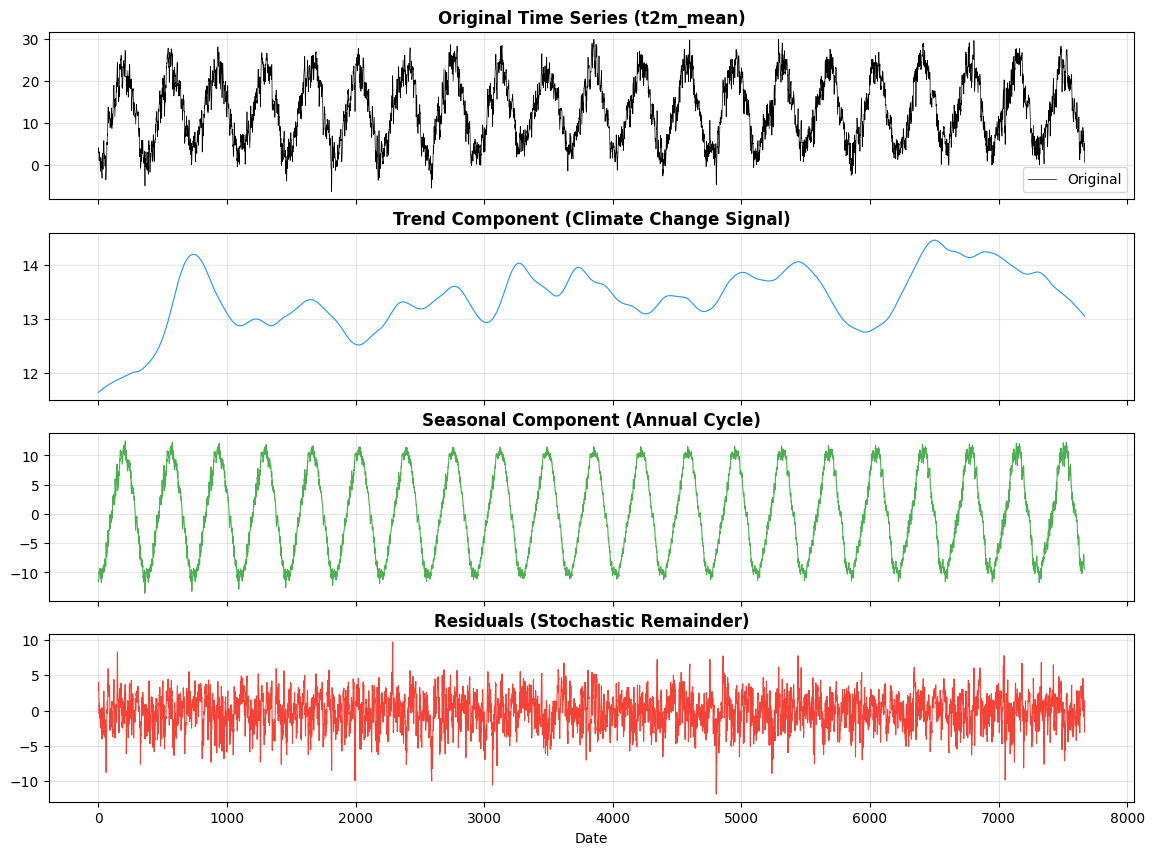

In [5]:
t2m_series = df_daily['t2m_mean']

# STL Decomposition
stl = STL(t2m_series, period=365, seasonal=101, robust=True)
result_stl = stl.fit()

#Extract the components
trend = result_stl.trend      # Climate change / long-term signal
seasonal = result_stl.seasonal  # The "Predictable" annual cycle
residuals = result_stl.resid    # The Stochastic Remainder (Invariants)

#Plot the components
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(t2m_series.index, t2m_series.values, color='black', lw=0.5, label='Original')
axes[0].set_title('Original Time Series (t2m_mean)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(trend.index, trend.values, color='#2196F3', lw=0.8)
axes[1].set_title('Trend Component (Climate Change Signal)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[2].plot(seasonal.index, seasonal.values, color='#4CAF50', lw=0.8)
axes[2].set_title('Seasonal Component (Annual Cycle)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[3].plot(residuals.index, residuals.values, color='#f44336', lw=0.8)
axes[3].set_title('Residuals (Stochastic Remainder)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

Estimated trend slope: 0.0796 D/year
Linear regression on trend: slope=0.0545 D/year, p-value=0.0013, R²=0.4294


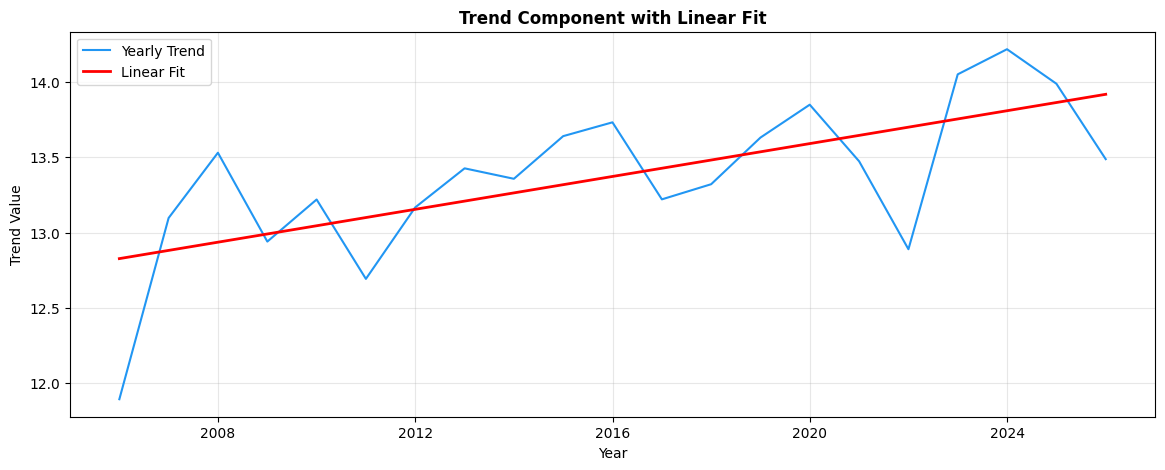

In [6]:

df_daily = df_daily.set_index('date')

#  Extract the trend (if you haven't already) 
# Let's assume 'trend' is a Series from your decomposition
# Ensure 'trend' itself has the datetime index
trend.index = df_daily.index 

#  Now resample will work
trend_yearly = trend.resample('YE').mean()

#  Calculate slope manually
years_array = trend_yearly.index.year
trend_slope = (trend_yearly.iloc[-1] - trend_yearly.iloc[0]) / (years_array[-1] - years_array[0])
print(f"Estimated trend slope: {trend_slope:.4f} D/year")

#  Linear regression
slope, intercept, r_value, p_value, std_err = linregress(years_array, trend_yearly.values)
print(f"Linear regression on trend: slope={slope:.4f} D/year, p-value={p_value:.4f}, R²={r_value**2:.4f}")

#  Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trend_yearly.index, trend_yearly.values, color='#2196F3', lw=1.5, label='Yearly Trend')
ax.plot(trend_yearly.index, intercept + slope * years_array, color='red', lw=2, label='Linear Fit')
ax.set_title('Trend Component with Linear Fit', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Trend Value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

# Check stationarity of the residuals using Augmented Dickey-Fuller test

def check_stationarity(series):
    # Perform Augmented Dickey-Fuller test
    # autolag='AIC' lets the test choose the best number of lags to remove autocorrelation
    result = adfuller(series, autolag='AIC')
    
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if result[1] <= 0.05:
        print("\nConclusion: Reject the Null Hypothesis. The residuals are STATIONARY.")
    else:
        print("\nConclusion: Fail to Reject the Null Hypothesis. The residuals are NON-STATIONARY.")

# Apply to your STL residuals
check_stationarity(result_stl.resid)

ADF Statistic: -28.247319
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567

Conclusion: Reject the Null Hypothesis. The residuals are STATIONARY.


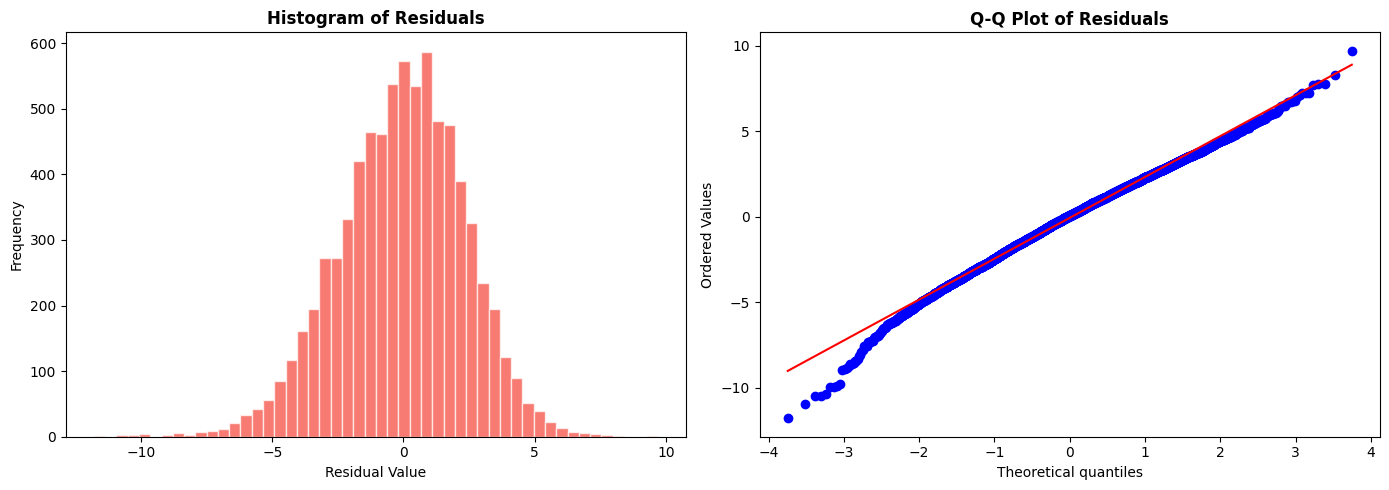

Jarque-Bera Statistic: 164.7289
Jarque-Bera p-value: 0.0000
Conclusion: Reject the Null Hypothesis. The residuals are NOT normally distributed.


In [8]:
# Check the distribution of the residuals
import scipy.stats as stats
# Plot histogram and Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(result_stl.resid, bins=50, color='#f44336', alpha=0.7, edgecolor='white')
axes[0].set_title('Histogram of Residuals', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Frequency')
stats.probplot(result_stl.resid, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# Perform Jarque-Bera test for normality
jb_stat, jb_p = stats.jarque_bera(result_stl.resid)
print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"Jarque-Bera p-value: {jb_p:.4f}")
if jb_p < 0.05:
    print("Conclusion: Reject the Null Hypothesis. The residuals are NOT normally distributed.")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis. The residuals are normally distributed.")
    

In [9]:
import joblib

# save the model on the subfolder Models
model_folder = Path("../Models")

model_path = model_folder / "temp_ste_model.joblib"

# Save the model
joblib.dump(result_stl, model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: ..\Models\temp_ste_model.joblib


Fitted Student's t-distribution parameters: ν=21.2755, loc=-0.0483, scale=2.2798


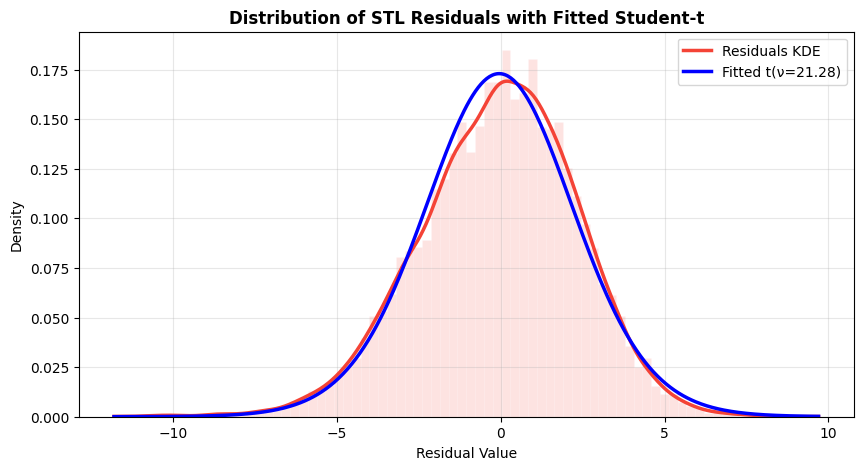

In [10]:
# Fit the residuals to a Student's t-distribution to check for heavy tails
from scipy import stats
t_df, t_loc, t_scale = stats.t.fit(result_stl.resid.dropna())
print(f"Fitted Student's t-distribution parameters: ν={t_df:.4f}, loc={t_loc:.4f}, scale={t_scale:.4f}")

# Plot the distribution of residuals with the fitted t-distribution
fig, ax = plt.subplots(figsize=(10, 5))
resid = result_stl.resid.dropna()
kde = stats.gaussian_kde(resid)
x_vals = np.linspace(resid.min(), resid.max(), 500)
ax.plot(x_vals, kde(x_vals), color='#f44336', lw=2.5, label='Residuals KDE')
ax.plot(x_vals, stats.t.pdf(x_vals, df=t_df, loc=t_loc, scale=t_scale), color='blue', lw=2.5, label=f'Fitted t(ν={t_df:.2f})')
ax.hist(resid, bins=80, density=True, color='#f44336', alpha=0.15, edgecolor='white')
ax.set_title('Distribution of STL Residuals with Fitted Student-t', fontsize=12, fontweight='bold')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


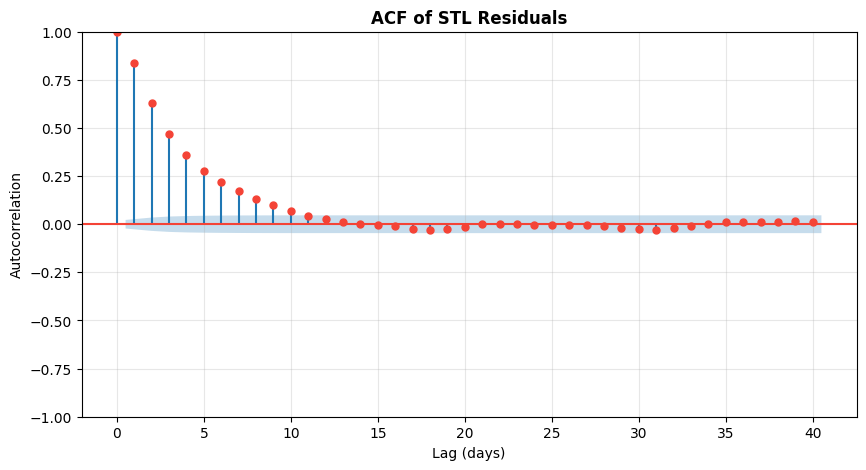

In [11]:
# Check the Autocorrelation of the residuals
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(result_stl.resid.dropna(), lags=40, ax=ax, color='#f44336')
ax.set_title('ACF of STL Residuals', fontsize=12, fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.grid(True, alpha=0.3)
plt.show()


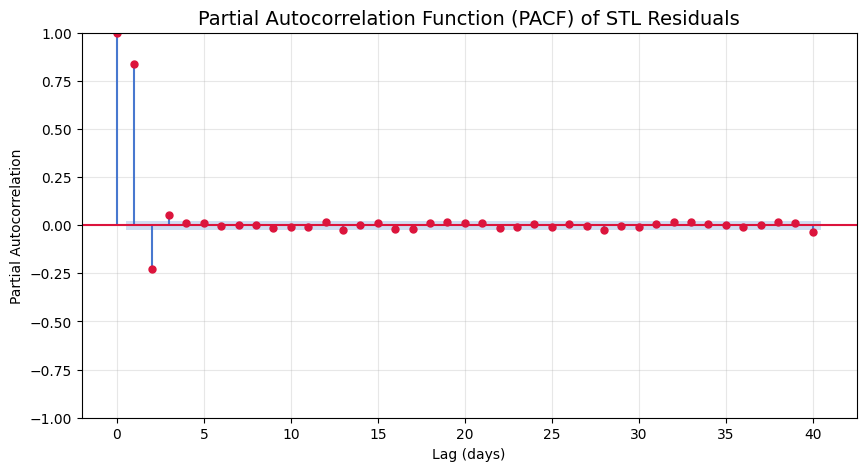

In [12]:

from statsmodels.graphics.tsaplots import plot_pacf

# Assuming 'residuals' is your STL residual series
# residuals = your_data

# Setting the style for a professional look
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(10, 5))

# Plotting the PACF
# 'lags=40' to match your ACF plot; 'method=ywm' is standard for stationarity
plot_pacf(residuals, lags=40, ax=ax, method='ywm', color='crimson', alpha=0.05)

ax.set_title('Partial Autocorrelation Function (PACF) of STL Residuals', fontsize=14)
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Partial Autocorrelation')
ax.grid(True, alpha=0.3)

plt.show()

The analysis showed that residuals of the decomposed series have a student t distribution, mean layer in order 2 and volatility clusters

## Modelling the invariants

### Using arch into temperature Levels

In [13]:
from arch import arch_model

# 1. Initialize the model
# residuals: your stationary STL residuals
# mean='AR': handles the PACF lags you saw
# lags=2: because lags 1 and 2 were significant in your PACF
# vol='ARCH': handles volatility clustering
# p=1: standard starting point for ARCH
# dist='t': uses the Student's t-distribution you identified
model = arch_model(residuals, mean='AR', lags=2, vol='ARCH', p=1, dist='t')

# 2. Fit the model
results_arch = model.fit(update_freq=5)

# Saving the residuals
residuals_arch = results_arch.resid

# 3. View the parameters
print(results_arch.summary())

Iteration:      5,   Func. Count:     53,   Neg. LLF: 12653.292342962866
Optimization terminated successfully    (Exit mode 0)
            Current function value: 12626.040578360873
            Iterations: 9
            Function evaluations: 83
            Gradient evaluations: 9
                              AR - ARCH Model Results                               
Dep. Variable:                        resid   R-squared:                       0.712
Mean Model:                              AR   Adj. R-squared:                  0.712
Vol Model:                             ARCH   Log-Likelihood:               -12626.0
Distribution:      Standardized Student's t   AIC:                           25264.1
Method:                  Maximum Likelihood   BIC:                           25305.8
                                              No. Observations:                 7668
Date:                      Fri, Mar 27 2026   Df Residuals:                     7665
Time:                              06:1

In [14]:
import joblib

# save the model on the subfolder Models
model_folder = Path("..\Models")

model_path = model_folder / "temp_arch_model.joblib"

# Save the model
joblib.dump(model, model_path)

print(f"Model successfully saved to: {model_path}")


Model successfully saved to: ..\Models\temp_arch_model.joblib


<>:4: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:4: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_5260\3728876735.py:4: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  model_folder = Path("..\Models")


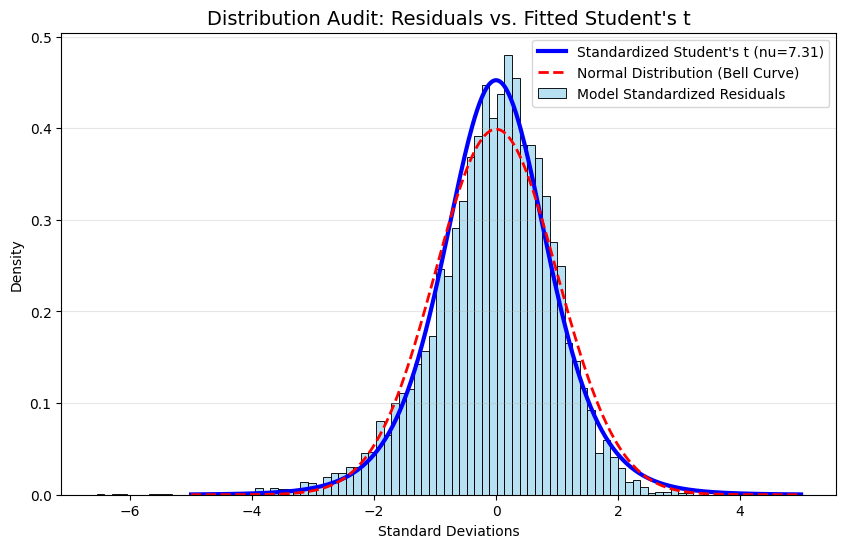

In [15]:

# 1. Extract the standardized residuals from ARCH model
# These are the values 'z' that the model assumes follow the t-distribution
std_resid = results_arch.std_resid

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Plot the actual histogram of your residuals
sns.histplot(std_resid, kde=False, stat="density", color='skyblue', alpha=0.6, label='Model Standardized Residuals')

# 3. Create the comparison curves
x = np.linspace(-5, 5, 500)

# Curve A: The Standardized Student's t (using your nu = 6.58)
# We use the standardized version where variance = 1
# For a t-dist, variance = nu / (nu - 2), so we scale to keep variance at 1
nu = 7.3081
scale_factor = np.sqrt((nu - 2) / nu)
pdf_t = stats.t.pdf(x, df=nu, loc=0, scale=scale_factor)
plt.plot(x, pdf_t, 'b-', lw=3, label=f"Standardized Student's t (nu={nu:.2f})")

# Curve B: Standard Normal (For comparison)
pdf_norm = stats.norm.pdf(x, 0, 1)
plt.plot(x, pdf_norm, 'r--', lw=2, label='Normal Distribution (Bell Curve)')

plt.title("Distribution Audit: Residuals vs. Fitted Student's t", fontsize=14)
plt.xlabel("Standard Deviations")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

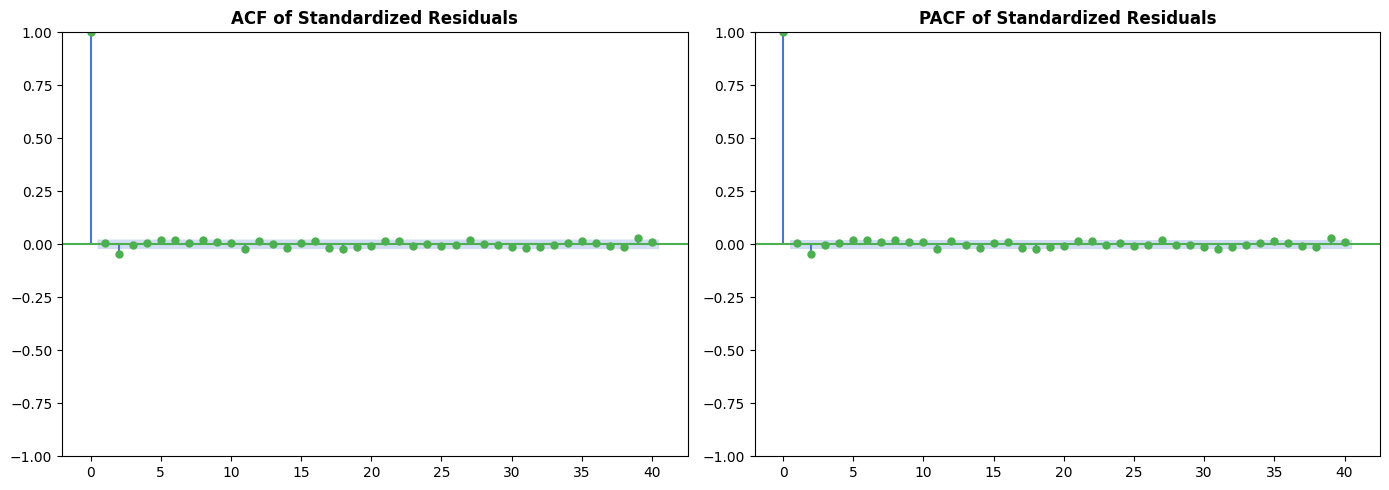

In [16]:
# Plot the ACF and PACF of the standardized residuals to check if the model captured the autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

std_resid = results_arch.std_resid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(std_resid.dropna(), lags=40, ax=axes[0], color='#4CAF50')
axes[0].set_title('ACF of Standardized Residuals', fontsize=12, fontweight='bold')
plot_pacf(std_resid.dropna(), lags=40, ax=axes[1], method='ywm', color='#4CAF50')
axes[1].set_title('PACF of Standardized Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:
# Performing the ACF of Squared Residuals $(\epsilon^2)$ and the Engle’s ARCH Test
arch_test_results = results_arch.arch_lm_test(lags=20)
print(arch_test_results)


ARCH-LM Test
H0: Residuals are homoskedastic.
ARCH-LM Test
H1: Residuals are conditionally heteroskedastic.
Statistic: 56.5218
P-value: 0.0000
Distributed: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000259F4934590>


In [18]:
pd.Series(results_arch.resid, index=df_daily.index)

date
2005-01-01   NaN
2005-01-02   NaN
2005-01-03   NaN
2005-01-04   NaN
2005-01-05   NaN
              ..
2025-12-27   NaN
2025-12-28   NaN
2025-12-29   NaN
2025-12-30   NaN
2025-12-31   NaN
Name: resid, Length: 7670, dtype: float64

In [19]:
results_arch.resid

0            NaN
1            NaN
2       1.012918
3      -0.524741
4       0.304394
          ...   
7665    1.316642
7666    0.649269
7667   -2.629141
7668   -0.437612
7669   -1.275705
Name: resid, Length: 7670, dtype: float64

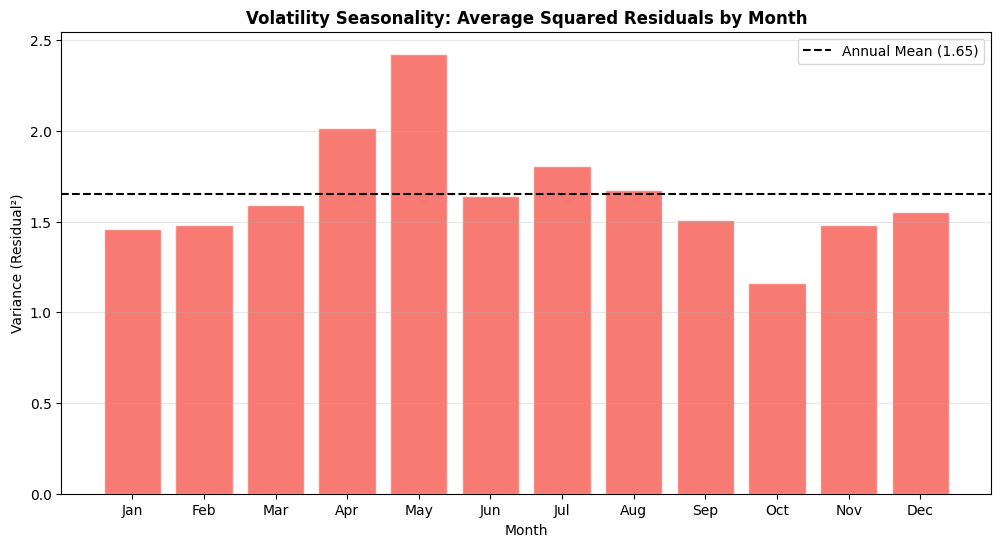

In [20]:

# 1. Extract residuals from the ARCH results object
# results_arch.resid returns a series or array of the residuals
# We explicitly re-index it with df_daily to ensure .index.month works
resid_series = pd.Series(results_arch.resid.values, index=df_daily.index)

# 2. Calculate Squared Residuals (Variance proxy)
resid_squared = resid_series ** 2

# 3. Group by Month and calculate the mean
# This works because resid_series now has the DatetimeIndex from df_daily
resid_squared_monthly = resid_squared.groupby(resid_squared.index.month).mean()

# 4. Plotting
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.bar(month_labels, resid_squared_monthly.values, color='#f44336', alpha=0.7, edgecolor='white')

# Adding a horizontal line for the annual average to identify "High Volatility" months
overall_mean = resid_squared.mean()
plt.axhline(overall_mean, color='black', linestyle='--', label=f'Annual Mean ({overall_mean:.2f})')

plt.title('Volatility Seasonality: Average Squared Residuals by Month', fontsize=12, fontweight='bold')
plt.ylabel('Variance (Residual²)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

plt.show()

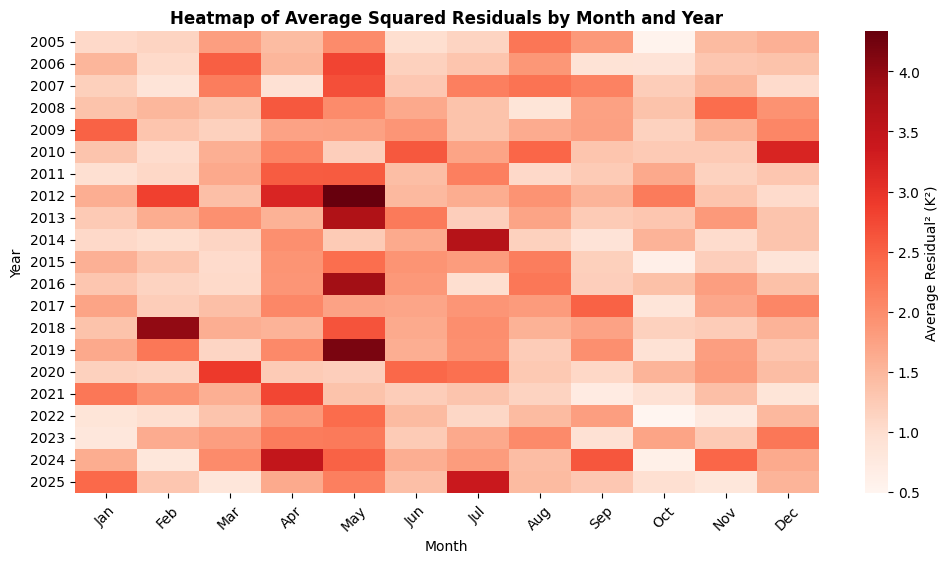

In [21]:
# Calculate the average squared residuals for each month and year to check for seasonal heteroskedasticity

resid_squared_monthly_yearly = resid_squared.groupby([resid_squared.index.year, resid_squared.index.month]).mean().unstack()

#Plot the heatmap of average squared residuals by month and year
plt.figure(figsize=(12, 6))
import seaborn as sns
sns.heatmap(resid_squared_monthly_yearly, cmap='Reds', cbar_kws={'label': 'Average Residual² (K²)'})
plt.title('Heatmap of Average Squared Residuals by Month and Year', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=np.arange(0.5, 12.5), labels=month_labels, rotation=45)
plt.yticks(rotation=0)
plt.show()


Although there is a seasonal heteroskedasticity, it is not clear through the years. Therefore it will first be considered as not significant

# Saving the modeled dataframe


In [22]:
# Store ARCH model outputs back into df_daily, aligned by date index
df_daily['arch_resid']     = results_arch.resid.values
df_daily['arch_std_resid'] = results_arch.std_resid.values
df_daily['arch_cond_vol']  = results_arch.conditional_volatility.values

# For the predicted value: 
df_daily['arch_predicted'] = residuals.values - results_arch.resid.values
df_daily = df_daily.reset_index()

In [23]:
df_daily

,date,t2m_mean,t2m_min,t2m_max,t2m_range,GHI_sum,GHI_cs_sum,Kt_daily,GHI_var,year,month,arch_resid,arch_std_resid,arch_cond_vol,arch_predicted
0,2005-01-01,3.294354,-0.008026,9.306305,9.314331,2119.085016,2127.852121,0.995880,20724.878099,2005,1,NaN,NaN,NaN,NaN
1,2005-01-02,3.554255,0.820953,8.043030,7.222076,1982.049556,2032.770931,0.975048,18715.490950,2005,1,NaN,NaN,NaN,NaN
2,2005-01-03,4.044258,-0.352631,9.871307,10.223938,1879.852110,1921.520051,0.978315,16677.484853,2005,1,1.012918,0.804468,1.259116,2.993889
3,2005-01-04,2.935619,-1.797668,10.199127,11.996796,2037.694044,2125.667418,0.958614,18199.426344,2005,1,-0.524741,-0.415287,1.263560,3.393608
4,2005-01-05,2.895000,-0.907440,9.043701,9.951141,1963.360307,2099.169946,0.935303,17187.529129,2005,1,0.304394,0.246319,1.235772,2.090352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7665,2025-12-27,4.348988,1.161530,9.983917,8.822388,2055.588290,2076.590182,0.989886,19103.966491,2025,12,1.316642,1.038983,1.267241,-0.876527
7666,2025-12-28,5.163586,1.215912,10.999054,9.783142,2122.258604,2124.960890,0.998728,20404.094902,2025,12,0.649269,0.503620,1.289205,0.718021
7667,2025-12-29,2.632848,-1.343445,6.763153,8.106598,2068.760437,2086.895966,0.991310,19346.796026,2025,12,-2.629141,-2.118169,1.241233,1.367733
7668,2025-12-30,1.831661,-1.768158,6.203766,7.971924,1326.291826,1951.388265,0.679666,8752.797697,2025,12,-0.437612,-0.299061,1.463288,-1.584219


In [24]:
df_daily = df_daily.drop(columns=['GHI_sum', 'GHI_cs_sum', 'Kt_daily', 'GHI_var', 'year', 'month'])

In [27]:
#Save the dataframe
OUTPUT_CLEAN = base_path / r"..\..\Data\Modelled\df_temperature_modeled.parquet"

df_daily.to_parquet(OUTPUT_CLEAN, index=True)
print(f"\n[SAVED] {OUTPUT_CLEAN}")
print(f"  Final shape: {df_daily.shape}")


[SAVED] c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Code\Modelling\..\..\Data\Modelled\df_temperature_modeled.parquet
  Final shape: (7670, 9)
